1. Importing the Dataset from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'telco-customer-churn-ibm-dataset' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-ibm-dataset


2. Importing pandas to load the dataset

In [2]:
import pandas as pd
import os

In [3]:
print(os.listdir(path))

['Telco_customer_churn.xlsx']


In [4]:
file_path = os.path.join(path, "Telco_customer_churn.xlsx")

df = pd.read_excel(file_path)

3. Checking if the dataset has loaded properly with no missing/null values or incorrect data types.

In [5]:
print(df)

      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

4. Removing the spaces in the column names so its easier to reference the columns.

In [8]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [9]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code',
       'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen',
       'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value',
       'Churn_Score', 'CLTV', 'Churn_Reason'],
      dtype='object')

5. Correcting the data type in the Total Charges Column. From object to numeric.

In [10]:
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")


In [11]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip_Code           7043 non-null   int64  
 6   Lat_Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior_Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure_Months      7043 non-null   int64  
 14  Phone_Service      7043 non-null   object 
 15  Multiple_Lines     7043 non-null   object 
 16  Internet_Service   7043 

6. Checking for Null/Missing values after changing the data type for the colunm, replacing the missing values as '0' indicating the customers have no charges


In [12]:
df["Total_Charges"].isnull().sum()

np.int64(11)

In [13]:
df["Total_Charges"].fillna(0, inplace=True)

/tmp/ipykernel_20867/1515472767.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Total_Charges"].fillna(0, inplace=True)


In [14]:
df["Total_Charges"].isnull().sum()

np.int64(0)

8.Working out the Churn rate (the percentage of customers/subscribers that stopped using its Service)

In [15]:
df["Churn"] = df["Churn_Value"]

In [16]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [17]:
churn_rate = df["Churn"].mean()

print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 26.54%


9. Showing the distribution between the customers who stay and leave

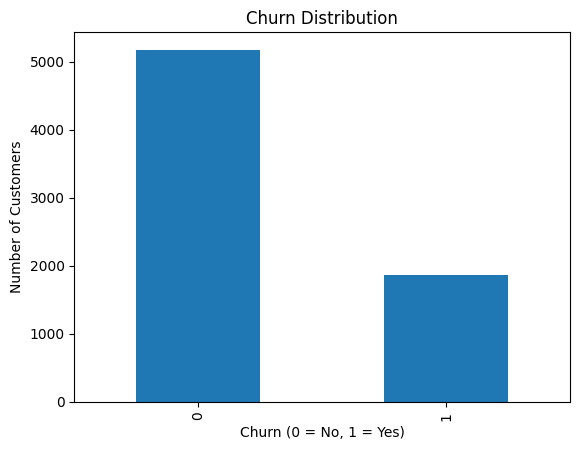

In [18]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

10. Showing the Churn rate by contract type. Month to month tend to have higher churn rate

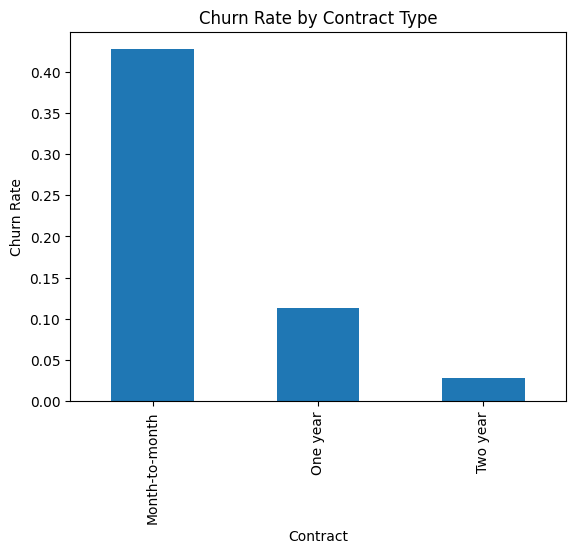

In [19]:
df.groupby("Contract")["Churn"].mean().plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

11. Showing the Churn rate by the monthly charges. Higher monthly charges appear to correlate with increased churn risk

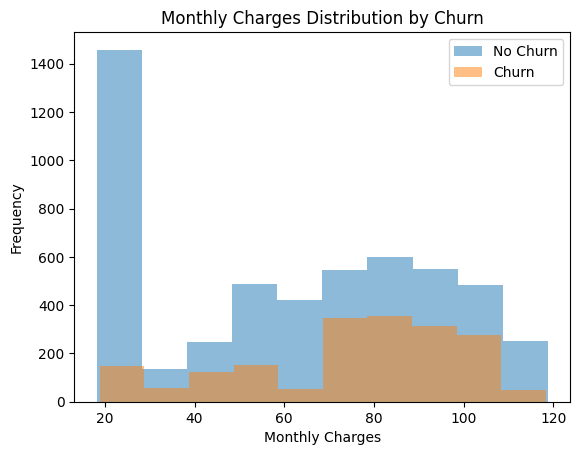

In [20]:
plt.hist(df[df["Churn"] == 0]["Monthly_Charges"], alpha=0.5, label="No Churn")
plt.hist(df[df["Churn"] == 1]["Monthly_Charges"], alpha=0.5, label="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.legend()
plt.show()


12. Showng the Churn rate by length of subscription. Customers are more likely to end their subscription earlier on.

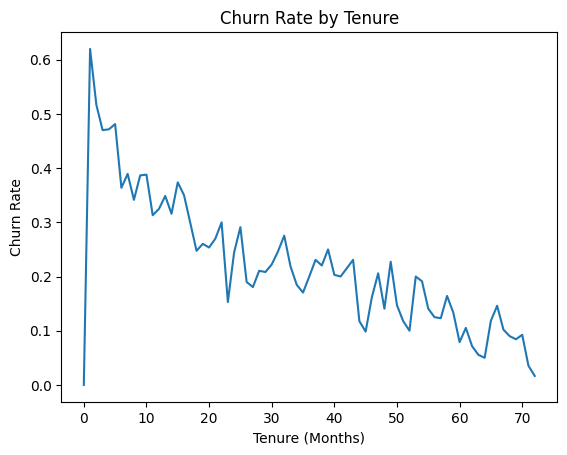

In [21]:
df.groupby("Tenure_Months")["Churn"].mean().plot()
plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.show()

 13. showing the Churn by payment type. Customers using electronic check show higher churn rates compared to other payment methods.

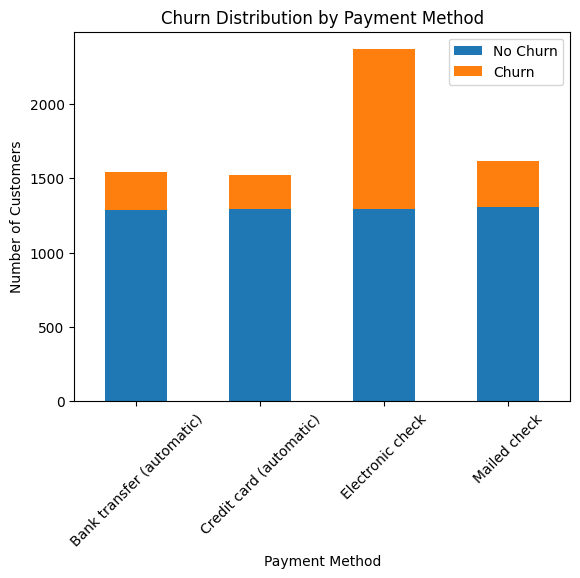

In [22]:

churn_payment = pd.crosstab(df["Payment_Method"], df["Churn"])


churn_payment.plot(kind="bar", stacked=True)

plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(["No Churn", "Churn"])
plt.show()

14. Churned customers reduce customer lifetime value.

In [23]:
df.groupby("Churn")["CLTV"].mean()

,CLTV
Churn,
0,4490.921337
1,4149.414660


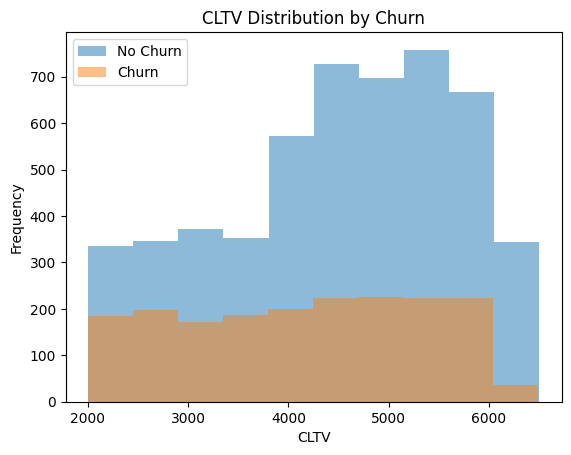

In [24]:
plt.hist(df[df["Churn"] == 0]["CLTV"], alpha=0.5, label="No Churn")
plt.hist(df[df["Churn"] == 1]["CLTV"], alpha=0.5, label="Churn")

plt.title("CLTV Distribution by Churn")
plt.xlabel("CLTV")
plt.ylabel("Frequency")
plt.legend()
plt.show()

14. Customer churn reasons.

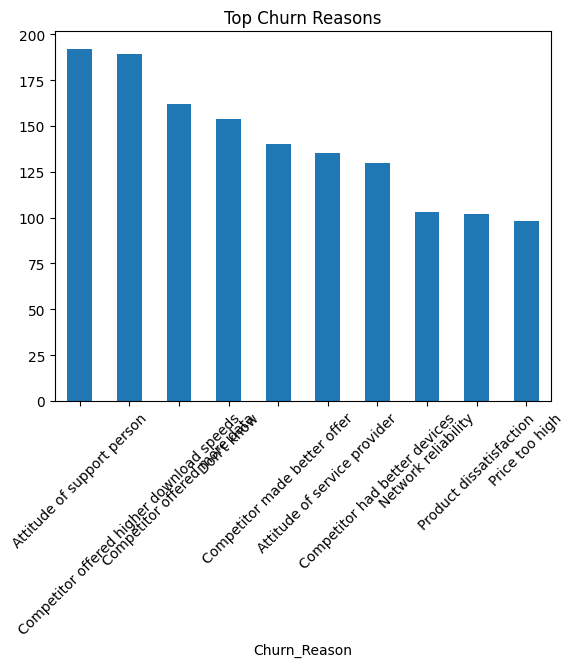

In [25]:
df["Churn_Reason"].value_counts().head(10).plot(kind="bar")
plt.title("Top Churn Reasons")
plt.xticks(rotation=45)
plt.show()

15. Dropping the irrelevant colunms for data modelling

In [26]:
df = df.drop(columns=["CustomerID", "Count", "Country", "State", "City", "Zip_Code", "Lat_Long"])

In [27]:
df_clean = df.copy()

df_clean.to_csv("customer_churn_dashboard.csv", index=False)

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.columns = df.columns.str.strip().str.replace(" ", "_")


X = df.drop(columns=["Churn", "Churn_Label", "Churn_Reason"], errors="ignore")
y = df["Churn"]


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1009    0]
 [   0  400]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [30]:
import pandas as pd

feature_importance = pd.Series(model.coef_[0], index=X.columns)
feature_importance.sort_values().tail(10)

,0
Churn_Reason_Product_dissatisfaction,0.262659
Churn_Reason_Price_too_high,0.284414
Churn_Reason_Network_reliability,0.337144
Churn_Reason_Competitor_made_better_offer,0.392527
Churn_Reason_Don't_know,0.428200
Churn_Reason_Competitor_offered_higher_download_speeds,0.441892
Churn_Reason_Attitude_of_support_person,0.474293
Churn_Reason_Competitor_offered_more_data,0.518396
Churn_Value,4.965198
Churn_Label_Yes,4.965198


Exporting the dataframe for visualisations

In [31]:
df.to_csv("customer_churn_cleaned.csv", index=False)

In [32]:
import os
print(os.getcwd())

/content


In [33]:
print(os.listdir())

['.config', 'customer_churn_cleaned.csv', 'sample_data']


In [34]:
df.columns

Index(['Latitude', 'Longitude', 'Tenure_Months', 'Monthly_Charges',
       'Total_Charges', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn',
       'Gender_Male', 'Senior_Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone_Service_Yes', 'Multiple_Lines_No_phone_service',
       'Multiple_Lines_Yes', 'Internet_Service_Fiber_optic',
       'Internet_Service_No', 'Online_Security_No_internet_service',
       'Online_Security_Yes', 'Online_Backup_No_internet_service',
       'Online_Backup_Yes', 'Device_Protection_No_internet_service',
       'Device_Protection_Yes', 'Tech_Support_No_internet_service',
       'Tech_Support_Yes', 'Streaming_TV_No_internet_service',
       'Streaming_TV_Yes', 'Streaming_Movies_No_internet_service',
       'Streaming_Movies_Yes', 'Contract_One_year', 'Contract_Two_year',
       'Paperless_Billing_Yes', 'Payment_Method_Credit_card_(automatic)',
       'Payment_Method_Electronic_check', 'Payment_Method_Mailed_check',
       'Churn_Label_Yes', 'Churn_Reas